In [1]:
from pathlib import Path

_EXPORT = "comparison2_yolo5n_export"
_RUN = "comparison2_yolo5n"


def _repo_root_with_run() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / _EXPORT / "runs" / _RUN).is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        f"Could not find {_EXPORT}/runs/{_RUN}; run the notebook from the repo root or Analysis/."
    )


BASE = str(_repo_root_with_run() / _EXPORT / "runs" / _RUN)


## **Part V: Multi-Version YOLO Comparison (YOLOv5n)**



### Experimental Settings

This is the second of three comparison models run as part of Part V.
The goal is to compare YOLOv11n (baseline) against other YOLO versions trained under identical conditions to evaluate how architecture differences affect performance on the VisDrone dataset.

All settings were kept identical to the Part I baseline to ensure a fair comparison:

| Setting | Baseline (YOLOv11n) | Comparison 2 (YOLOv5n) |
|---|---|---|
| Dataset | VisDrone2019 | VisDrone2019 |
| Image Size | 640 | 640 |
| Batch Size | 16 | 16 |
| Max Epochs | 200 | 200 |
| Patience | 50 | 50 |
| **Model** | **YOLOv11n** | **YOLOv5n** |

The only difference is the model version. YOLOv5n is an earlier-generation nano model in the YOLO family and is included here to see how its behavior compares with the baseline under the same training pipeline on VisDrone.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = f"{BASE}/results.csv"

df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()

# final epoch metrics
final = df.iloc[-1]
print("=== Final Epoch Results ===")
print(f"mAP@50:        {final['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95:     {final['metrics/mAP50-95(B)']:.4f}")
print(f"Precision:     {final['metrics/precision(B)']:.4f}")
print(f"Recall:        {final['metrics/recall(B)']:.4f}")
print(f"Train Box Loss:{final['train/box_loss']:.4f}")
print(f"Val Box Loss:  {final['val/box_loss']:.4f}")

=== Final Epoch Results ===
mAP@50:        0.3401
mAP@50-95:     0.1943
Precision:     0.4353
Recall:        0.3441
Train Box Loss:1.3523
Val Box Loss:  1.4359


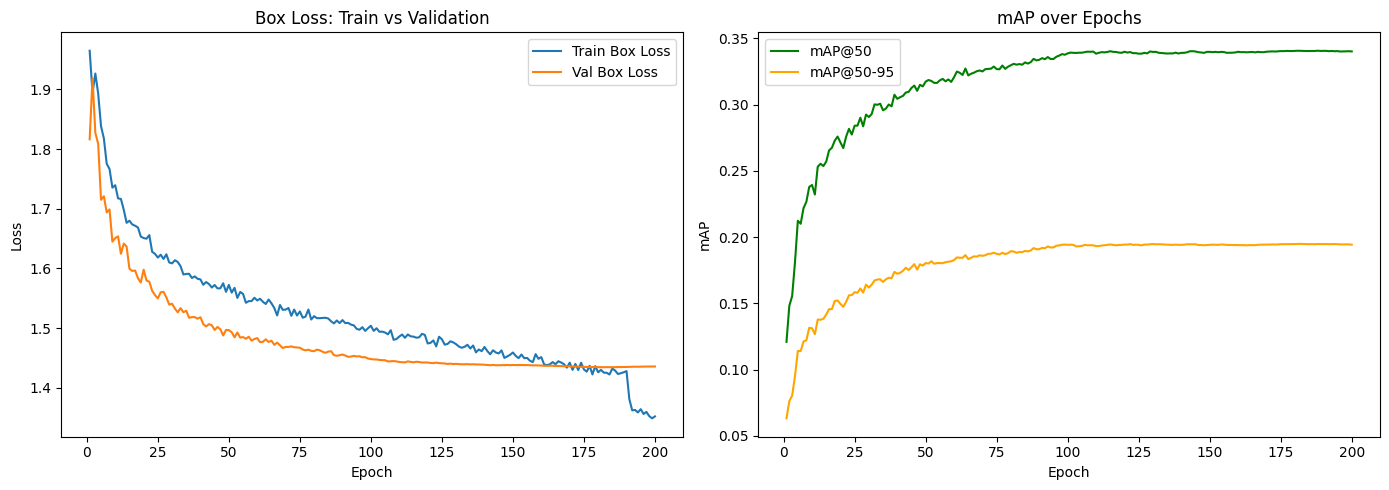

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
axes[0].set_title('Box Loss: Train vs Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# mAP curve
axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
axes[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='orange')
axes[1].set_title('mAP over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{BASE}/loss_map_curves.png", dpi=150)
plt.show()

In [4]:
summary = {
    "Model": ["YOLOv11n"],
    "Epochs": [len(df)],
    "mAP@50": [round(final['metrics/mAP50(B)'], 4)],
    "mAP@50-95": [round(final['metrics/mAP50-95(B)'], 4)],
    "Precision": [round(final['metrics/precision(B)'], 4)],
    "Recall": [round(final['metrics/recall(B)'], 4)],
}
pd.DataFrame(summary)

,Model,Epochs,mAP@50,mAP@50-95,Precision,Recall
0,YOLOv11n,200,0.3401,0.1943,0.4353,0.3441


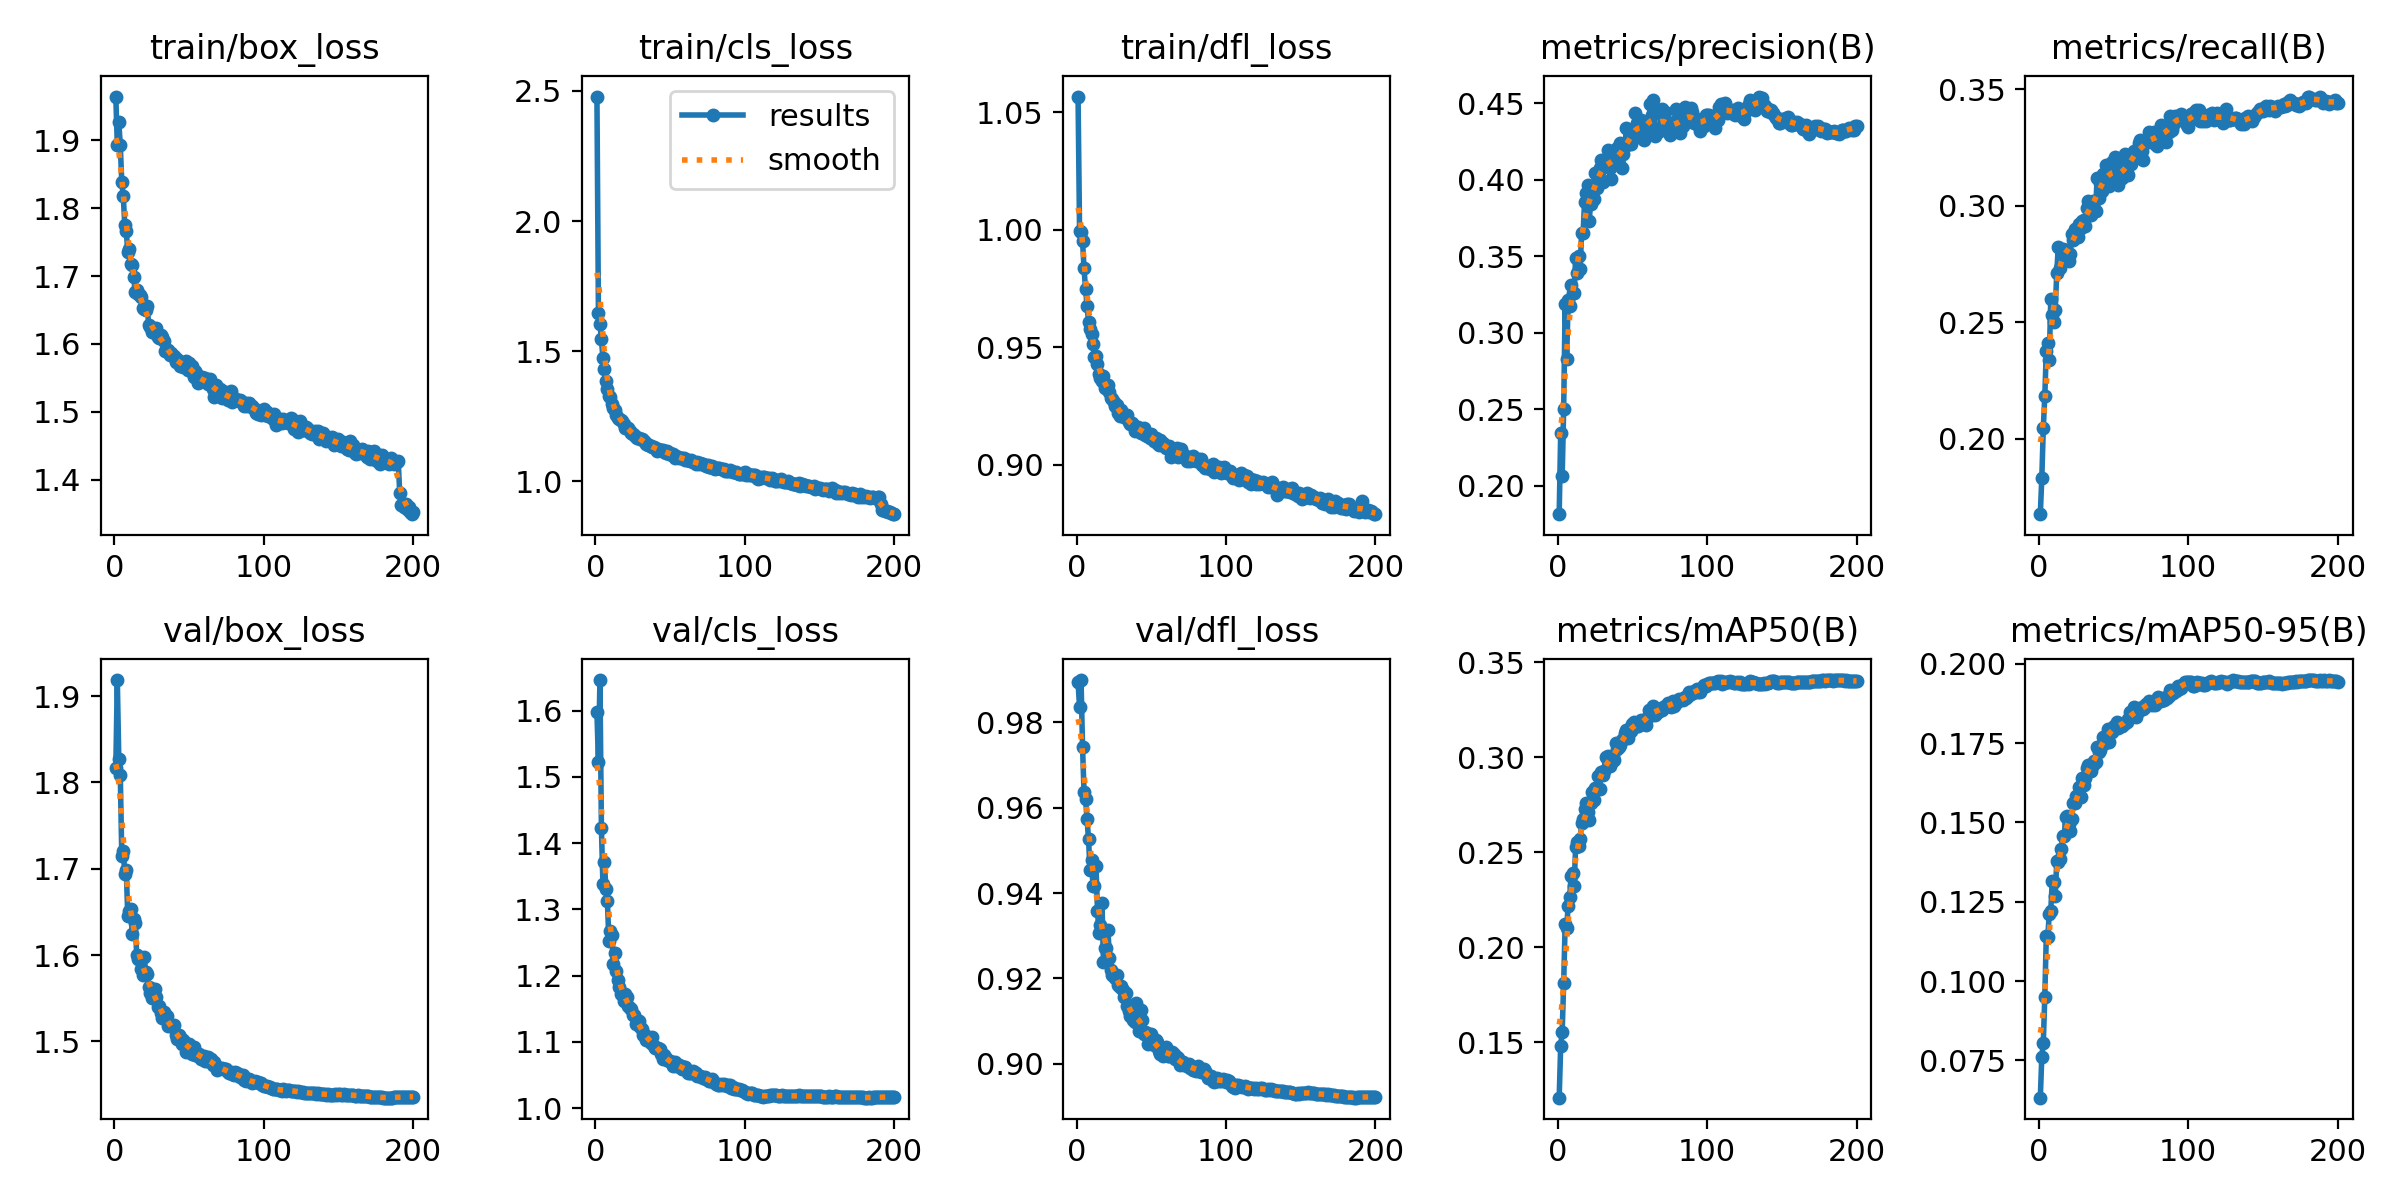

In [5]:
from IPython.display import Image, display
display(Image(f"{BASE}/results.png"))

### **Discussion**

**Note:** 200 epochs were set with a patience of 50 during training. Comparison 2 (YOLOv5n) ran the full 200 epochs, so early stopping did not trigger and training continued through epoch 200. The Part I baseline export stops earlier (final epoch 179), which is expected when early stopping fires under the same patience.

### 1. Training vs. Validation Loss

The loss curves above plot the **box loss** for both the training set and the validation set across all 200 epochs. The key observations are:

- Both curves decrease steadily through training, showing that the model keeps learning object detection features.
- The curves slow down after approximately epoch 100–120 but still show gradual improvement toward epoch 200.
- At the final epoch (epoch 200), the **training box loss is 1.3523** and the **validation box loss is 1.4359**, a gap of roughly **0.084** (validation higher than training).

The validation loss sits above the training loss, which indicates **mild overfitting**: the model fits the training set a bit more easily than it generalizes to validation. The gap is larger than in the baseline (~0.025 at the baseline’s last epoch), so the train/val mismatch is more visible here than for YOLOv11n, but the two curves still move together without a sharp late divergence.

### 2. Convergence Behavior

The run reached **epoch 200** without patience-based early stopping. That suggests optimization was still producing small improvements (or at least stable monitored metrics) within the last 50 epochs rather than sitting completely flat.

Final metrics settle near **mAP@50 0.340** and **mAP@50-95 0.194**, slightly below the baseline’s **0.349** and **0.201** at its best epoch. Training and validation box losses (~1.35 train vs ~1.44 val) are in a similar overall range to the baseline’s box losses (~1.39 train vs ~1.41 val), but the larger train/val gap points to somewhat weaker generalization on box loss for YOLOv5n in this setup.

### 3. Results Curves (results.png)

The results.png panel shows training and validation losses alongside precision, recall, mAP@50, and mAP@50-95 across all 200 epochs.

Training losses decrease without wild instability. Validation losses largely follow training but remain higher by the end of training, consistent with the **~0.084** box-loss gap.

Precision stabilizes near **0.435**, a bit below the baseline precision (**~0.447**). Recall settles close to **0.344**, essentially in line with the baseline recall (**~0.347**). The mAP curves rise through most of training and flatten somewhat toward the end; **mAP@50 0.3401** remains slightly under the baseline **0.3494**, suggesting comparable but not stronger detection quality for this architecture under the same schedule.

The gap between **mAP@50 (0.3401)** and **mAP@50-95 (0.1943)** is similar in spirit to the baseline, meaning localization is harder than coarse localization here as well.



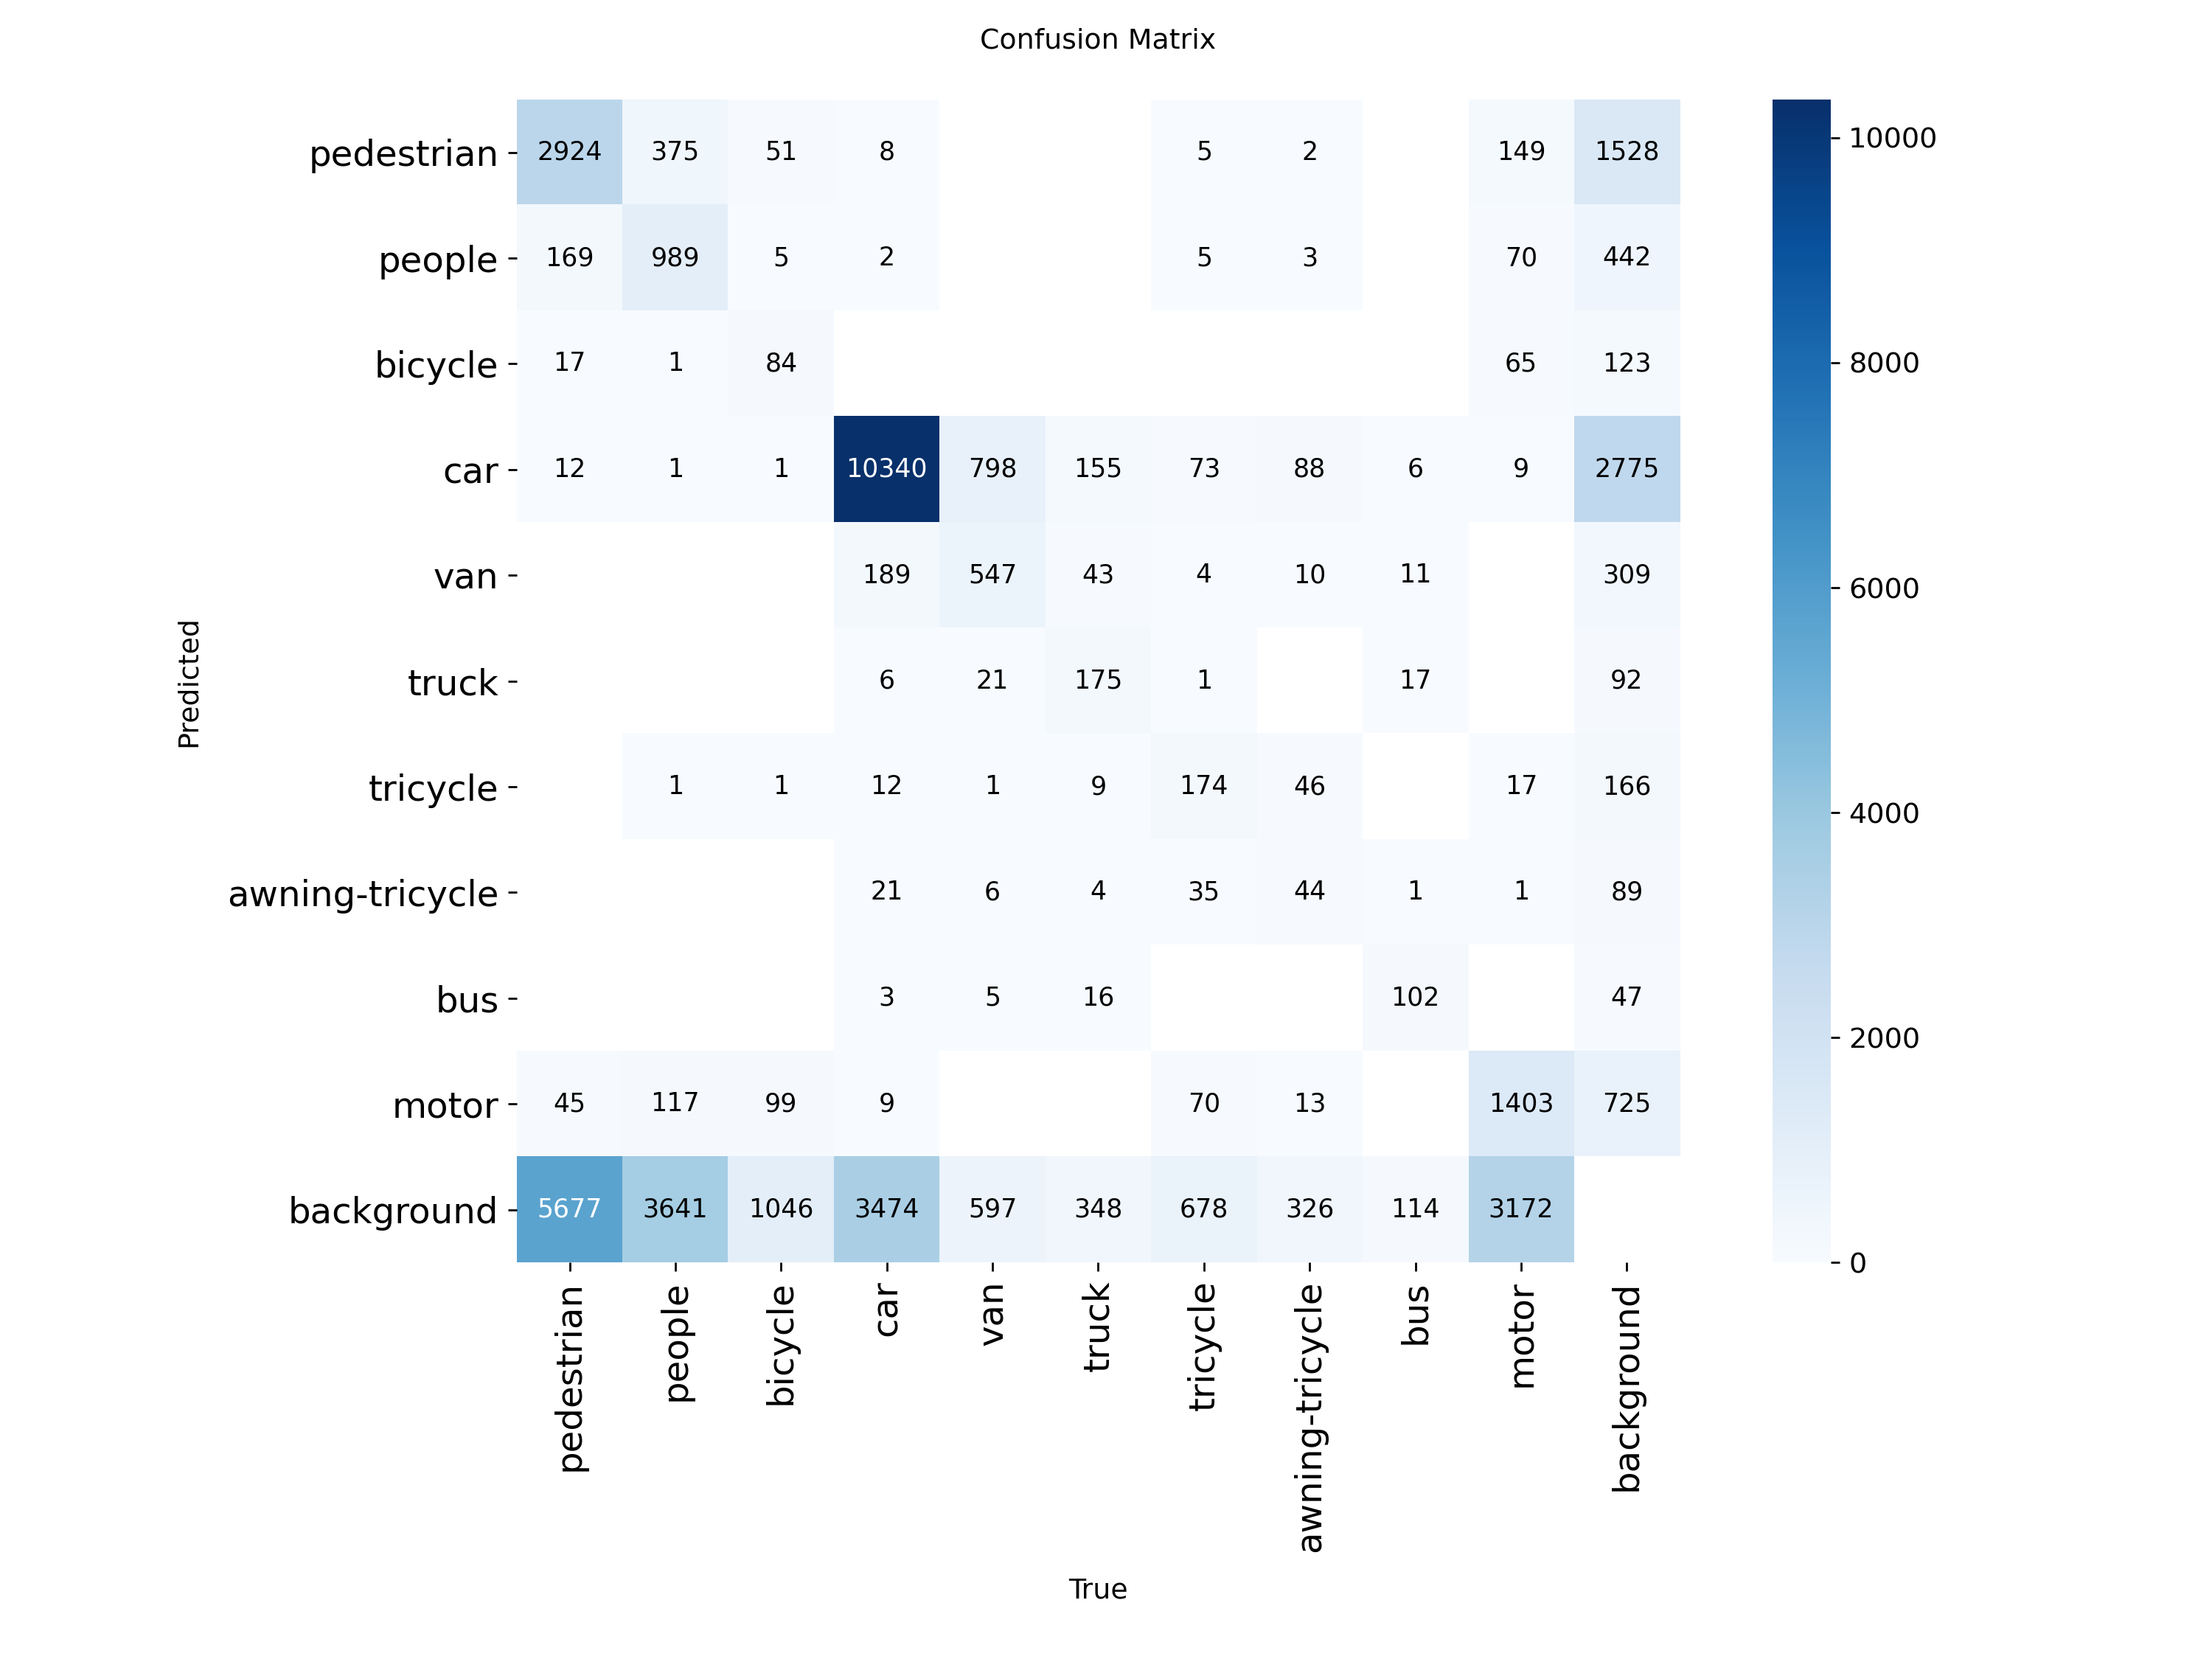

In [6]:
display(Image(f"{BASE}/confusion_matrix.png"))

### **Discussion**

### 4. Confusion Matrix

The confusion matrix shows detections across **all 10 classes**, consistent with previous runs on the same dataset.
The overall pattern remains similar to YOLOv11n: **car** is the easiest class, and small or rare categories are hardest.

**Car:**
Cars remain the strongest class, as expected from frequency and size in the images.

**Pedestrian and People:**
Pedestrian and people behave like the baseline: cross-class confusion between the two shows up because they look alike at drone resolution and scale.

**Bicycle, Tricycle, and Awning-Tricycle:**
These classes stay the weakest. They are small and uncommon, so the model often misses them or confuses them with background or nearby classes.

**Bus and Van:**
Bus and van look broadly like the baseline runs, with occasional confusion between van and car or truck.

**Overall:**
Background remains a large sink for missed objects, so precision can exceed recall. Here, **recall (~0.344)** is slightly below **precision (~0.435)**, similar to the baseline imbalance between finding objects and being confident about class labels. Switching to YOLOv5n does not remove these dataset-driven effects.



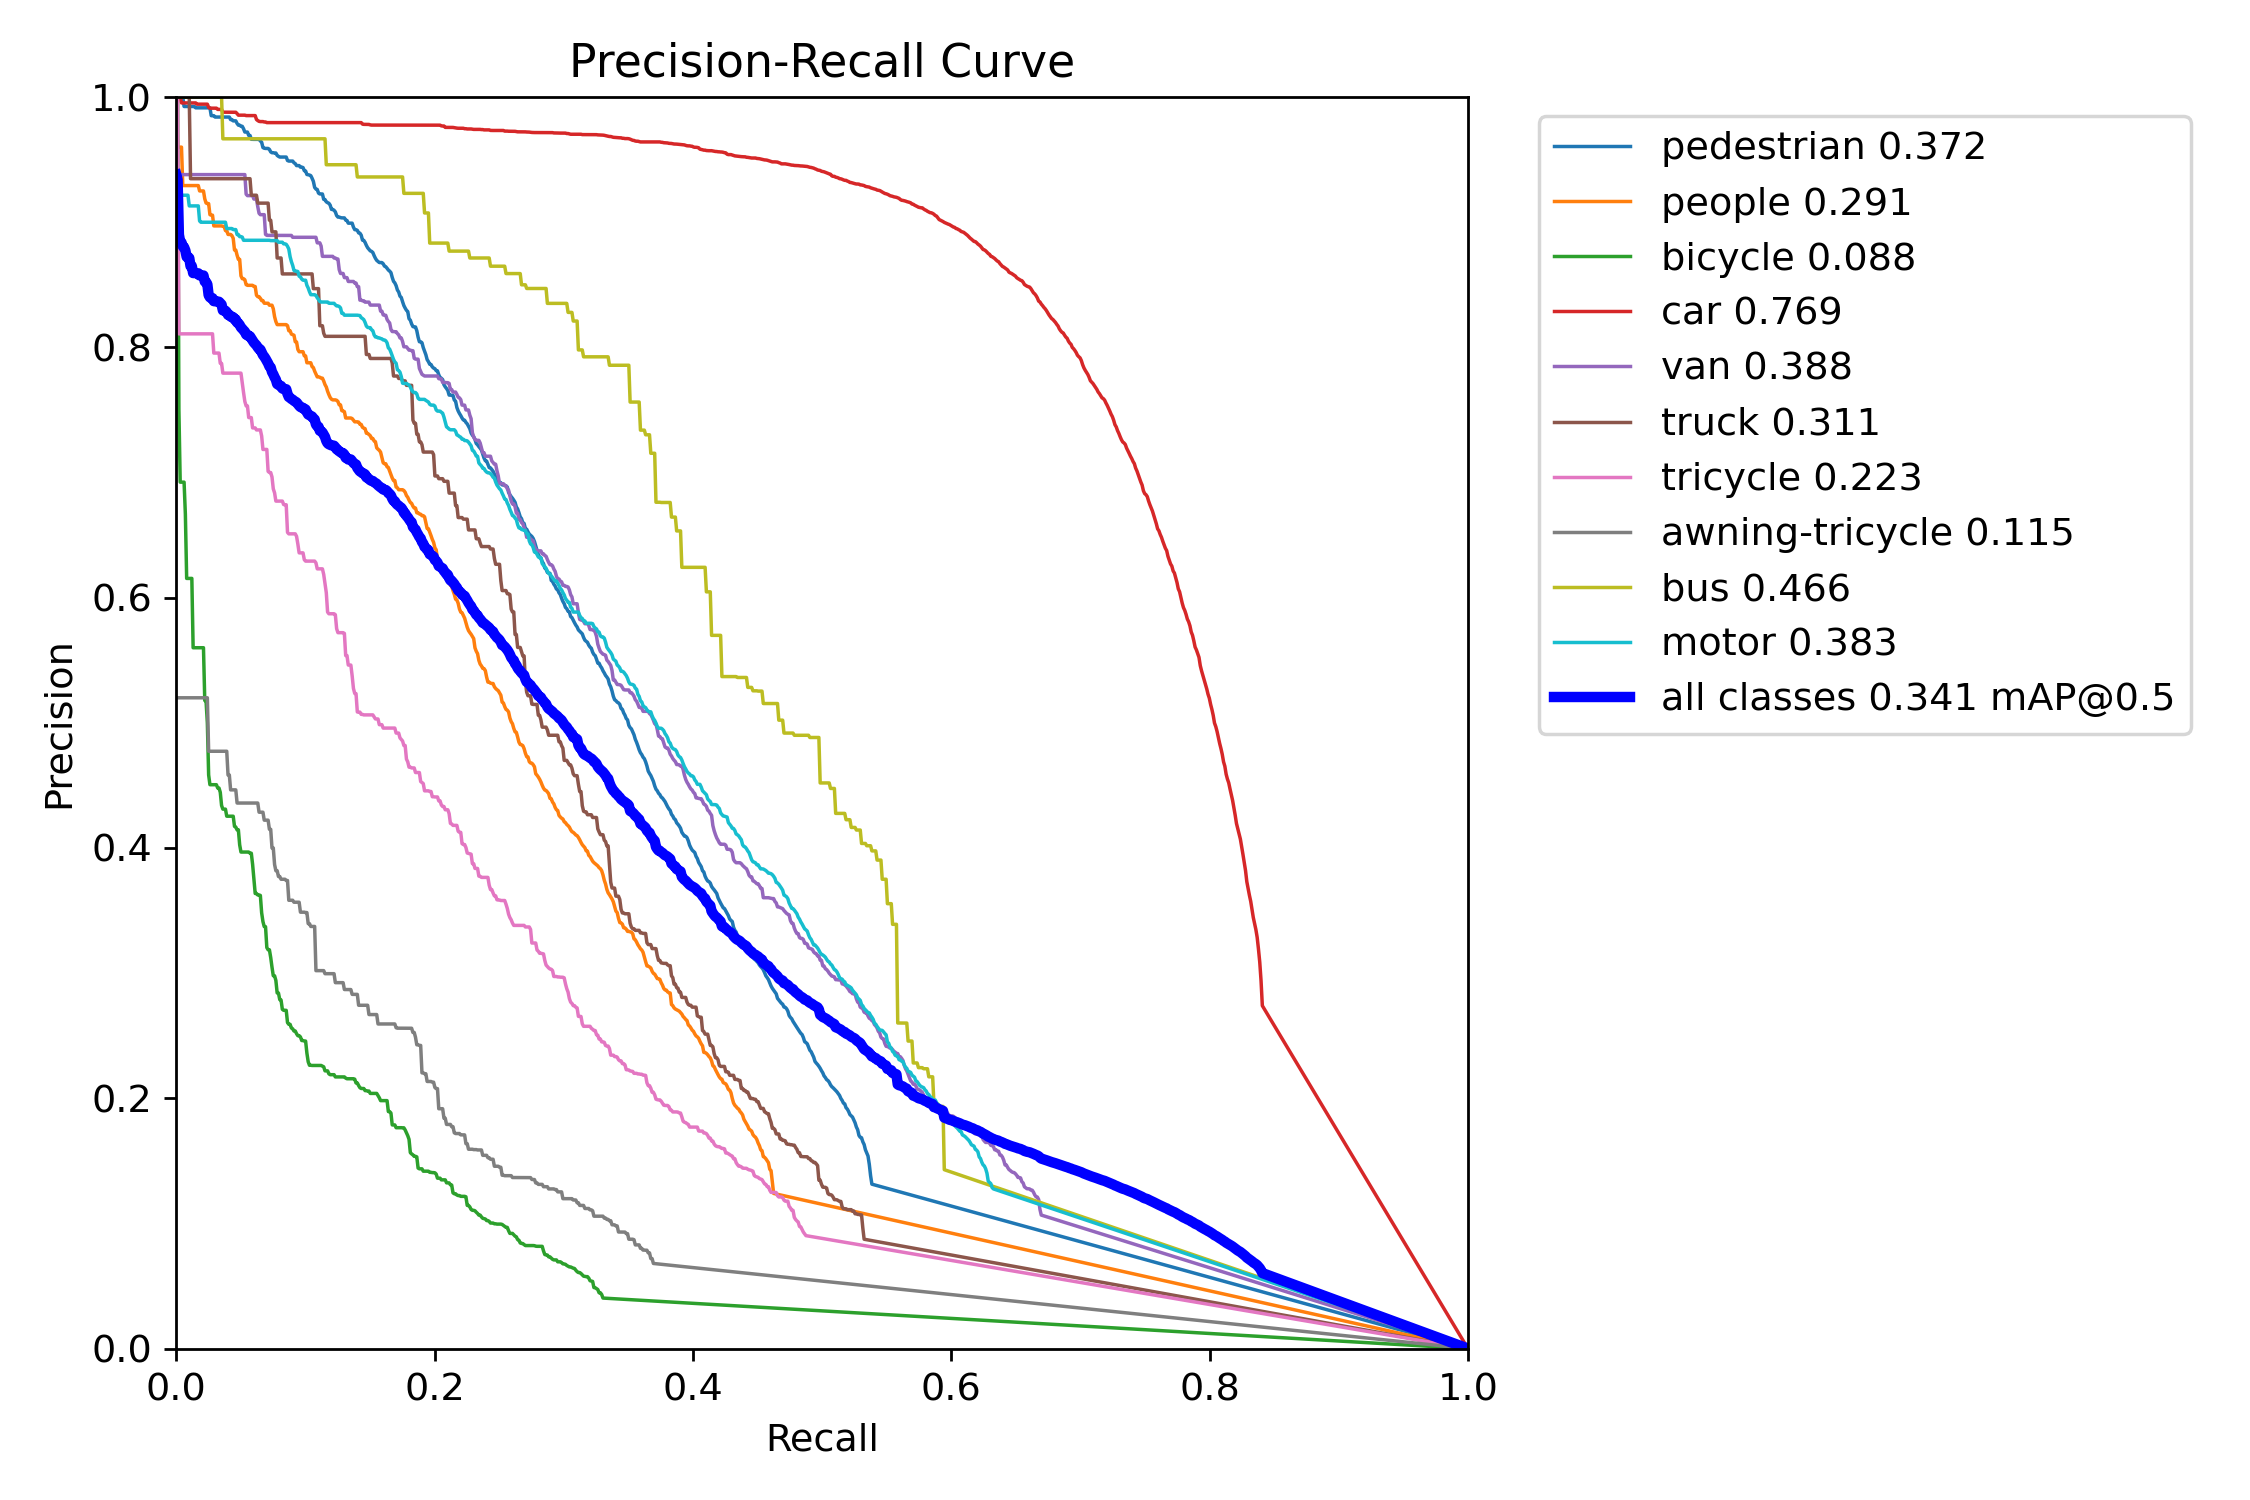

In [7]:
display(Image(f"{BASE}/BoxPR_curve.png"))

### 5. PR Curve (Precision Recall Curve)

The PR curve plots precision against recall at varying confidence thresholds for each class, with the area under each curve representing the per-class average precision.

**Car** keeps the strongest curve, matching prior VisDrone runs.

**Motor** and **bus** outperform the weakest classes, with precision that holds up better before recall is pushed high.

**Pedestrian** and **people** drop in precision earlier than car, reflecting the same confusion seen in the confusion matrix.

**Bicycle, tricycle, and awning-tricycle** show the steepest trade-offs: lowering the confidence threshold to recover recall quickly erodes precision.

The overall **mAP@50 of 0.3401** is slightly below the YOLOv11n baseline (**0.3494**) under the same training settings. That suggests YOLOv5n does not gain a clear edge on this dataset in this experiment, while still delivering a coherent learning curve across 200 epochs.



### **Discussion Summary**

### 6. Overfitting Analysis

**Mild overfitting is present** in this run. Evidence:

- Final **training** box loss (**1.3523**) is lower than **validation** box loss (**1.4359**), with a gap near **0.084**.
- The validation curve tracks training but sits above it, which is the classic sign of some memorization or easier fit on the training split.
- The gap is **larger than** the baseline’s train/val box gap (**~0.025**), so generalization on box loss is **worse than** YOLOv11n here, though not catastrophic.

### 7. Underfitting Analysis

The model does **not** look severely underfit: losses fall over 200 epochs and mAP reaches a reasonable plateau. The more accurate statement is **slightly lower headline mAP** than the baseline (0.3401 vs 0.3494), not a failure to learn. If anything, the mild overfitting suggests capacity is adequate; the shortfall versus the baseline is more plausibly due to **architecture and optimization differences** between YOLOv5n and YOLOv11n than to the model being too small to train.

### 8. Causes: Architecture and Train/Val Gap

**Architecture:**

YOLOv5n uses a different backbone, neck, and training defaults than YOLOv11n. Older and newer YOLO lines can converge differently on the same data, even when image size, batch, epochs, and patience are matched in this project. Here, YOLOv5n ends a bit **below** the baseline on mAP@50 while showing a **wider** train/val loss gap.

**Generalization gap:**

The larger validation box loss relative to training suggests YOLOv5n is slightly more sensitive to the train/validation split on VisDrone than YOLOv11n under this schedule. Stronger regularization, longer schedules, or architecture-specific tuning might narrow that gap, but those were outside the controlled comparison.



In [8]:
summary = {
    "Model": ["YOLOv11n"],
    "Epochs": [len(df)],
    "mAP@50": [round(final['metrics/mAP50(B)'], 4)],
    "mAP@50-95": [round(final['metrics/mAP50-95(B)'], 4)],
    "Precision": [round(final['metrics/precision(B)'], 4)],
    "Recall": [round(final['metrics/recall(B)'], 4)],
}
pd.DataFrame(summary)

,Model,Epochs,mAP@50,mAP@50-95,Precision,Recall
0,YOLOv11n,200,0.3401,0.1943,0.4353,0.3441


**Summary Table:**

| Observation | What Was Seen | Possible Reason |
|---|---|---|
| Mild overfitting | Validation box loss > training (gap ~0.084) | Train/val mismatch larger than baseline (~0.025); different inductive bias and optimization in YOLOv5n |
| Full 200 epochs | Patience did not stop training early | Metric still changing slowly or optimizer still updating in late epochs |
| Slightly lower mAP@50 | 0.3401 vs baseline 0.3494 | YOLOv5n does not outperform YOLOv11n here under identical configured training |
| Precision a bit lower | ~0.435 vs baseline ~0.447 | Comparable recall-driven limits; precision-confinement trades may differ by architecture |



### **Part V Note**

This is the **second** of three comparison models in Part V.
YOLOv5n reaches similar qualitative behavior to the baseline (same dominant classes, same hard rare classes) but finishes with **slightly lower mAP@50** and a **wider train/val box-loss gap**, indicating a bit less favorable generalization on this task under the chosen settings.
Results from all three comparison models will be compiled into a final structured comparison table in the Part V summary notebook.

